# Baseline modeling - XGBoost

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report,
    precision_score, precision_recall_curve, auc, average_precision_score
)

from xgboost import XGBClassifier

In [22]:
import os
import pandas as pd

PROJECT_ROOT = '../../../'

csv_path = os.path.join(PROJECT_ROOT, '00_data', '01_interim', 'train.csv')

data_df = pd.read_csv(csv_path, low_memory=False)

final_df = data_df[['pid']]
final_df.head()

,pid
0,10002
1,40002
2,40004
3,100001
4,100002


In [23]:
# -----------------------------
# 2. target / feature 분리
# -----------------------------
X = data_df.drop('is_churned', axis=1)
y = data_df['is_churned']

# pid 제거 (식별자 컬럼이면 보통 제거)
if 'pid' in X.columns:
    X = X.drop(columns=['pid'])

In [24]:
# -----------------------------
# 3. Train / Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
# -----------------------------
# 4. 클래스 불균형 비율 계산
# -----------------------------
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

scale_pos_weight = neg_count / pos_count
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 1.7636363636363637


In [26]:
# -----------------------------
# 5. XGBoost 모델
# -----------------------------
model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

# -----------------------------
# 6. CV 설정
# -----------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -----------------------------
# 7. 평가 지표 설정
# -----------------------------
scoring = {
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

# -----------------------------
# 8. Cross Validation 수행
# -----------------------------
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

# -----------------------------
# 9. CV 결과 출력
# -----------------------------
print("CV Recall:", cv_results['test_recall'].mean())
print("CV F1-score:", cv_results['test_f1'].mean())
print("CV ROC-AUC:", cv_results['test_roc_auc'].mean())
print("CV PR-AUC:", cv_results['test_pr_auc'].mean())

CV Recall: 0.4
CV F1-score: 0.40892909386556564
CV ROC-AUC: 0.5763270188939865
CV PR-AUC: 0.4306807720936706


In [27]:
# -----------------------------
# 10. 모델 학습
# -----------------------------
model.fit(X_train, y_train)

# -----------------------------
# 11. 테스트 예측
# -----------------------------
pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)[:, 1]

# -----------------------------
# 12. 테스트 평가
# -----------------------------
print("\nClassification Report")
print(classification_report(y_test, pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, pred))

print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1-score:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
print("PR-AUC:", average_precision_score(y_test, pred_proba))


Classification Report
              precision    recall  f1-score   support

           0       0.69      0.74      0.71       291
           1       0.47      0.42      0.44       165

    accuracy                           0.62       456
   macro avg       0.58      0.58      0.58       456
weighted avg       0.61      0.62      0.62       456

Confusion Matrix
[[214  77]
 [ 96  69]]
Precision: 0.4726027397260274
Recall: 0.41818181818181815
F1-score: 0.4437299035369775
ROC-AUC: 0.6239091950432156
PR-AUC: 0.5051028589133948


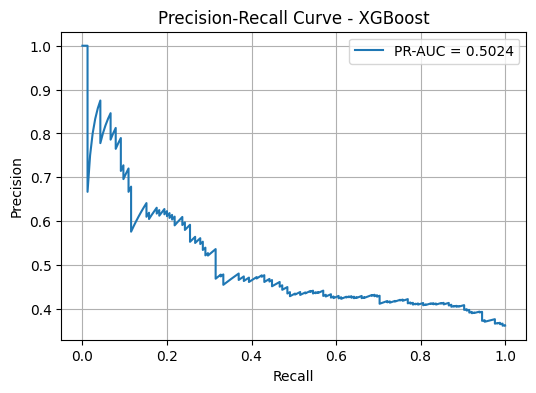

In [28]:
precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

## Baseline XGBoost 모델 결과 해석

Baseline XGBoost 모델의 테스트 결과는 다음과 같다.

- Precision(이탈 고객 기준): **0.473**
- Recall(이탈 고객 기준): **0.418**
- F1-score(이탈 고객 기준): **0.444**
- ROC-AUC: **0.624**
- PR-AUC: **0.505**

Confusion Matrix는 다음과 같다.

| Actual / Predicted | 0 | 1 |
|---|---|---|
| 0 | 214 | 77 |
| 1 | 96 | 69 |

이 결과는 모델이 비이탈 고객과 이탈 고객을 어느 정도 구분하고는 있으나, 프로젝트의 핵심 목표인 **이탈 고객 탐지 성능**은 아직 충분하지 않음을 보여준다.
실제 이탈 고객은 165명이었고, 이 중 **69명만 이탈로 탐지**했으며 **96명은 놓쳤다**. 따라서 Recall은 **0.418**로, 실제 이탈 고객의 절반 이상을 탐지하지 못한 상태이다.

Precision은 **0.473**으로, 모델이 이탈이라고 예측한 고객 중 실제 이탈 고객의 비율이 절반에 못 미친다.
즉, 현재 모델은 이탈 고객을 충분히 많이 잡아내지도 못하고, 동시에 이탈로 예측한 결과의 정확도도 아주 높지는 않은 상태라고 볼 수 있다.

또한 F1-score는 **0.444**로 나타나 Precision과 Recall의 균형 역시 제한적이다.
이는 모델이 현재 threshold 0.5 기준에서 이탈 고객을 탐지하는 데 다소 보수적으로 작동하고 있음을 시사한다.

ROC-AUC는 **0.624**로, 전체적인 클래스 구분 능력이 아주 강하지는 않다.
PR-AUC 역시 **0.505** 수준으로 나타났는데, 이는 양성 클래스인 이탈 고객을 우선적으로 잘 구분하는 성능이 아직 높지 않다는 의미이다. Precision-Recall Curve에서도 Recall을 높여갈수록 Precision이 비교적 빠르게 낮아지는 패턴이 나타나, 이탈 고객 탐지 성능의 안정성이 충분하지 않음을 확인할 수 있다.

프로젝트 목표와 비교하면 다음과 같이 모든 핵심 지표가 기준에 미달한다.

| Metric | Result | Target |
|---|---|---|
| Recall | 0.418 | ≥ 0.70 |
| F1-score | 0.444 | ≥ 0.60 |
| ROC-AUC | 0.624 | ≥ 0.75 |
| PR-AUC | 0.505 | ≥ 0.75 |

종합하면, Baseline XGBoost 모델은 현재 단계에서 **Random Forest의 초기 버전보다는 이탈 고객 탐지 성능이 개선된 모습**을 보이지만, 여전히 프로젝트 목표를 만족할 정도의 성능에는 도달하지 못했다.
특히 본 프로젝트는 이탈 고객을 놓치지 않는 것이 가장 중요하므로, 이후 단계에서는 **하이퍼파라미터 튜닝**, **scale_pos_weight 조정**, **threshold tuning**, **추가 feature engineering** 등을 통해 Recall을 더 끌어올릴 필요가 있다.

# Hyperparameter Optimization

In [29]:
from sklearn.model_selection import RandomizedSearchCV

In [30]:
# -----------------------------
# 13. Hyperparameter Optimization
# -----------------------------
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 1.2, scale_pos_weight * 1.5]
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        objective='binary:logistic',
        eval_metric='logloss'
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring='recall',
    cv=cv,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best CV Recall:", random_search.best_score_)

best_model = random_search.best_estimator_

Best Params: {'subsample': 0.7, 'scale_pos_weight': np.float64(2.6454545454545455), 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV Recall: 0.6590909090909091


In [31]:
pred = best_model.predict(X_test)
pred_proba = best_model.predict_proba(X_test)[:, 1]

print("\nTuned Model Evaluation")
print(classification_report(y_test, pred))

print("Confusion Matrix")
print(confusion_matrix(y_test, pred))

print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1-score:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
print("PR-AUC:", average_precision_score(y_test, pred_proba))


Tuned Model Evaluation
              precision    recall  f1-score   support

           0       0.74      0.47      0.58       291
           1       0.43      0.72      0.54       165

    accuracy                           0.56       456
   macro avg       0.59      0.59      0.56       456
weighted avg       0.63      0.56      0.56       456

Confusion Matrix
[[137 154]
 [ 47 118]]
Precision: 0.4338235294117647
Recall: 0.7151515151515152
F1-score: 0.540045766590389
ROC-AUC: 0.6485056753097991
PR-AUC: 0.5489950116122186


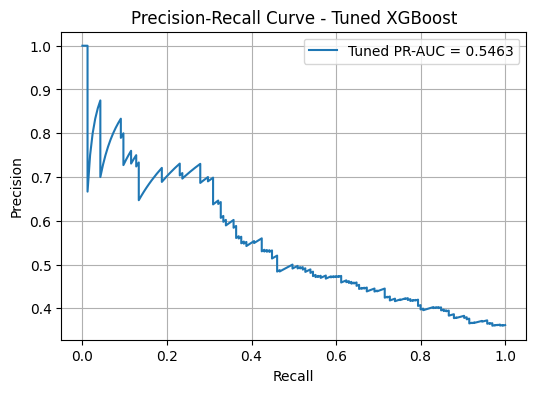

In [32]:
precision, recall, thresholds = precision_recall_curve(y_test, pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'Tuned PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Tuned XGBoost')
plt.legend()
plt.grid(True)
plt.show()

## Hyperparameter Optimization 후 XGBoost 모델 결과 해석

Hyperparameter Optimization을 적용한 XGBoost 모델의 테스트 결과는 다음과 같다.

- Precision(이탈 고객 기준): **0.434**
- Recall(이탈 고객 기준): **0.715**
- F1-score(이탈 고객 기준): **0.540**
- ROC-AUC: **0.649**
- PR-AUC: **0.549**

Confusion Matrix는 다음과 같다.

| Actual / Predicted | 0 | 1 |
|---|---|---|
| 0 | 137 | 154 |
| 1 | 47 | 118 |

이 결과는 baseline XGBoost와 비교했을 때, **이탈 고객 탐지 성능이 크게 향상되었다**는 점에서 의미가 있다.
실제 이탈 고객 165명 중 **118명을 이탈로 탐지**하고 **47명만 놓쳤다**. 이에 따라 Recall은 **0.418 → 0.715**로 크게 상승하였다. 이는 본 프로젝트의 핵심 목표인 **이탈 고객을 놓치지 않는 것**에 보다 부합하는 결과이며, 목표 기준인 **Recall 0.70 이상**도 충족하였다.

반면, Recall이 크게 향상된 대신 비이탈 고객을 이탈로 잘못 예측한 사례(False Positive)도 증가하였다.
비이탈 고객 291명 중 **154명**을 이탈로 분류하여, precision은 **0.434** 수준에 머물렀다. 즉, 모델이 이탈 고객을 적극적으로 탐지하는 방향으로 바뀌면서, 실제로는 이탈하지 않을 고객까지 함께 이탈로 분류하는 경향이 강해졌다고 해석할 수 있다.

F1-score는 **0.540**으로 baseline보다 개선되었지만, 여전히 목표 기준인 **0.60 이상**에는 미달한다.
이는 Recall을 확보하는 데는 성공했지만, precision이 낮아져 전체적인 균형은 아직 충분하지 않다는 의미이다.

ROC-AUC는 **0.649**, PR-AUC는 **0.549**로 baseline보다 소폭 개선되었으나, 클래스 전반의 구분 능력과 양성 클래스 중심 성능 모두 아직 강하다고 보기 어렵다.
특히 PR-AUC가 0.55 수준이라는 점은 이탈 고객을 우선적으로 잘 구분하는 성능이 완전히 안정적인 수준은 아니라는 점을 보여준다.

프로젝트 목표와 비교하면 다음과 같다.

| Metric | Result | Target |
|---|---|---|
| Recall | 0.715 | ≥ 0.70 |
| F1-score | 0.540 | ≥ 0.60 |
| ROC-AUC | 0.649 | ≥ 0.75 |
| PR-AUC | 0.549 | ≥ 0.75 |

종합하면, Hyperparameter Optimization 후 XGBoost 모델은 **Recall 측면에서 가장 의미 있는 개선**을 보였으며, 현재까지의 실험 결과 중 프로젝트 목적에 가장 가까운 방향의 모델이라고 볼 수 있다.
다만 precision이 낮고 false positive가 많아 운영 효율성 측면에서는 한계가 있다. 따라서 이후 단계에서는 **threshold tuning을 통한 precision-recall 균형 조정**, **feature engineering 강화**, **추가적인 불균형 처리 전략 적용** 등을 통해 F1-score와 PR-AUC를 함께 개선할 필요가 있다.

In [39]:
threshold_list = np.arange(0.9, 0.05, -0.05)

threshold_result = []

for threshold in threshold_list:
    pred_threshold = (pred_proba >= threshold).astype(int)

    threshold_result.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred_threshold, zero_division=0),
        "recall": recall_score(y_test, pred_threshold),
        "f1": f1_score(y_test, pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_result)
threshold_df

,threshold,precision,recall,f1
0,0.90,1.000000,0.012121,0.023952
1,0.85,0.857143,0.036364,0.069767
2,0.80,0.727273,0.096970,0.171123
3,0.75,0.702128,0.200000,0.311321
4,0.70,0.645570,0.309091,0.418033
5,0.65,0.546875,0.424242,0.477816
6,0.60,0.494048,0.503030,0.498498
7,0.55,0.461883,0.624242,0.530928
8,0.50,0.433824,0.715152,0.540046
9,0.45,0.411950,0.793939,0.542443


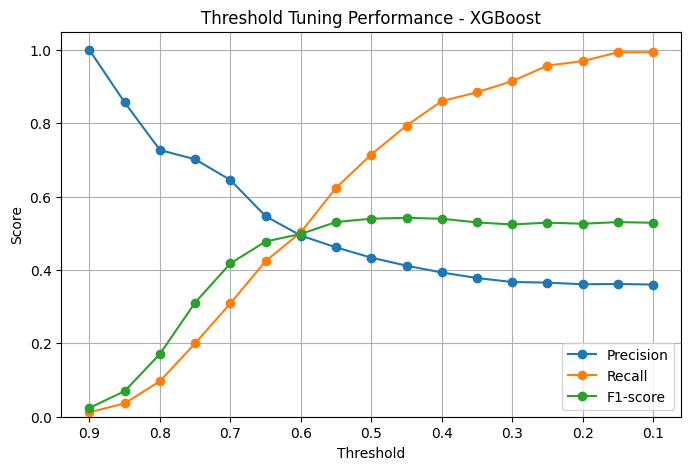

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df['threshold'],
    threshold_df['precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['threshold'],
    threshold_df['f1'],
    marker='o',
    label='F1-score'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning Performance - XGBoost')
plt.gca().invert_xaxis()
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

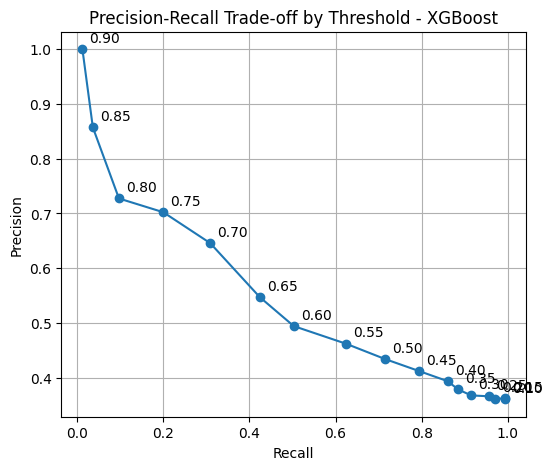

In [41]:
plt.figure(figsize=(6, 5))

plt.plot(
    threshold_df['recall'],
    threshold_df['precision'],
    marker='o'
)

for _, row in threshold_df.iterrows():
    plt.annotate(
        f"{row['threshold']:.2f}",
        (row['recall'], row['precision']),
        textcoords="offset points",
        xytext=(5, 5)
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off by Threshold - XGBoost')
plt.grid(True)
plt.show()

In [34]:
threshold_df.sort_values(by='recall', ascending=False)

,threshold,precision,recall,f1_score,roc_auc,pr_auc
5,0.25,0.365741,0.957576,0.529313,0.648506,0.548995
4,0.30,0.367397,0.915152,0.524306,0.648506,0.548995
3,0.35,0.378238,0.884848,0.529946,0.648506,0.548995
2,0.40,0.393352,0.860606,0.539924,0.648506,0.548995
1,0.45,0.411950,0.793939,0.542443,0.648506,0.548995
0,0.50,0.433824,0.715152,0.540046,0.648506,0.548995


In [35]:
best_threshold = 0.35
pred_final = (pred_proba >= best_threshold).astype(int)

print(f"\n[Final Model - Threshold = {best_threshold}]")
print(classification_report(y_test, pred_final))

print("Confusion Matrix")
print(confusion_matrix(y_test, pred_final))

print("Precision:", precision_score(y_test, pred_final))
print("Recall:", recall_score(y_test, pred_final))
print("F1-score:", f1_score(y_test, pred_final))
print("ROC-AUC:", roc_auc_score(y_test, pred_proba))
print("PR-AUC:", average_precision_score(y_test, pred_proba))


[Final Model - Threshold = 0.35]
              precision    recall  f1-score   support

           0       0.73      0.18      0.28       291
           1       0.38      0.88      0.53       165

    accuracy                           0.43       456
   macro avg       0.55      0.53      0.41       456
weighted avg       0.60      0.43      0.37       456

Confusion Matrix
[[ 51 240]
 [ 19 146]]
Precision: 0.37823834196891193
Recall: 0.8848484848484849
F1-score: 0.52994555353902
ROC-AUC: 0.6485056753097991
PR-AUC: 0.5489950116122186


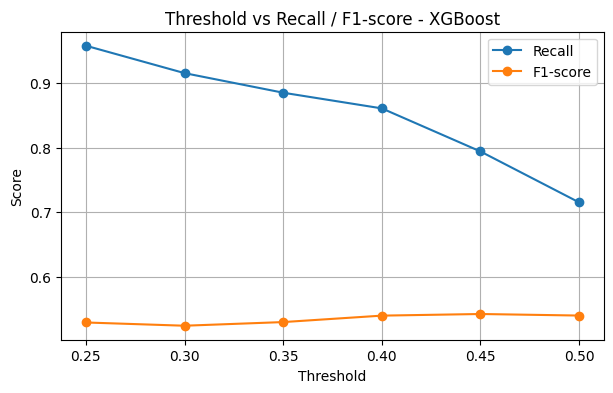

In [36]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
plt.plot(threshold_df['threshold'], threshold_df['f1_score'], marker='o', label='F1-score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold vs Recall / F1-score - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

## Threshold Tuning 후 XGBoost 모델 결과 해석

Threshold를 **0.35**로 조정한 XGBoost 모델의 테스트 결과는 다음과 같다.

- Precision(이탈 고객 기준): **0.378**
- Recall(이탈 고객 기준): **0.885**
- F1-score(이탈 고객 기준): **0.530**
- ROC-AUC: **0.649**
- PR-AUC: **0.549**

Confusion Matrix는 다음과 같다.

| Actual / Predicted | 0 | 1 |
|---|---|---|
| 0 | 51 | 240 |
| 1 | 19 | 146 |

이 결과는 threshold tuning을 통해 모델이 **이탈 고객을 매우 적극적으로 탐지하도록 조정되었음**을 보여준다.
실제 이탈 고객 165명 중 **146명을 이탈로 탐지**하고 **19명만 놓쳤기 때문에**, Recall은 **0.885**까지 크게 상승하였다. 이는 현재 실험 결과 중 가장 높은 수준의 이탈 고객 탐지 성능이며, 본 프로젝트의 핵심 목표인 **이탈 고객을 놓치지 않는 것**에는 가장 부합하는 결과이다.

반면, Recall이 크게 향상된 만큼 False Positive도 매우 크게 증가하였다.
실제 비이탈 고객 291명 중 **240명**을 이탈로 예측하여, 비이탈 고객 분류 성능은 크게 저하되었다. 그 결과 precision은 **0.378**까지 낮아졌고, accuracy도 **0.43**으로 하락하였다. 즉, 모델이 이탈 가능성이 조금이라도 있는 고객을 넓게 잡아내는 방향으로 바뀌면서, 실제로는 이탈하지 않을 고객도 대량으로 이탈로 분류하는 상태가 되었다.

F1-score는 **0.530**으로, threshold tuning 이전의 tuned XGBoost 모델(**0.540**)보다 오히려 소폭 하락하였다.
이는 Recall은 크게 좋아졌지만 Precision 손실이 더 커서, 전체적인 균형은 개선되지 않았음을 의미한다. 다시 말해, **이탈 고객을 놓치지 않는 성능은 강화되었지만, 너무 많은 고객을 이탈 위험군으로 분류하는 과탐지(over-prediction) 문제가 발생한 것**으로 해석할 수 있다.

Threshold 변화 그래프를 보면 threshold를 낮출수록 Recall은 빠르게 증가하지만, F1-score는 큰 폭으로 개선되지 않고 거의 비슷한 수준에서 유지된다.
특히 **0.40~0.45 구간에서는 Recall과 F1-score의 균형이 상대적으로 더 안정적**이며, **0.35 이하에서는 Recall은 더 높아지지만 Precision 손실이 매우 커지는 패턴**이 나타난다. 따라서 운영 목적에 따라 threshold를 다르게 선택할 필요가 있다.

- **이탈 고객을 최대한 놓치지 않는 것이 최우선**이면: `0.35`가 유리
- **Recall과 Precision의 균형도 함께 고려**하면: `0.40` 또는 `0.45`가 더 적절할 가능성 있음

# Feature Importance

In [37]:
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(20)

,feature,importance
12,mobile_charge_monthly,0.071327
8,information_evaluation_ability,0.070425
7,privacy,0.069812
11,age_group,0.066391
14,ott_usage_weekday,0.065425
15,ott_usage_weekend,0.064894
5,mobile_skills,0.061765
9,newtech_perception,0.061436
2,internet_ability,0.060822
10,newtech_impact,0.060813


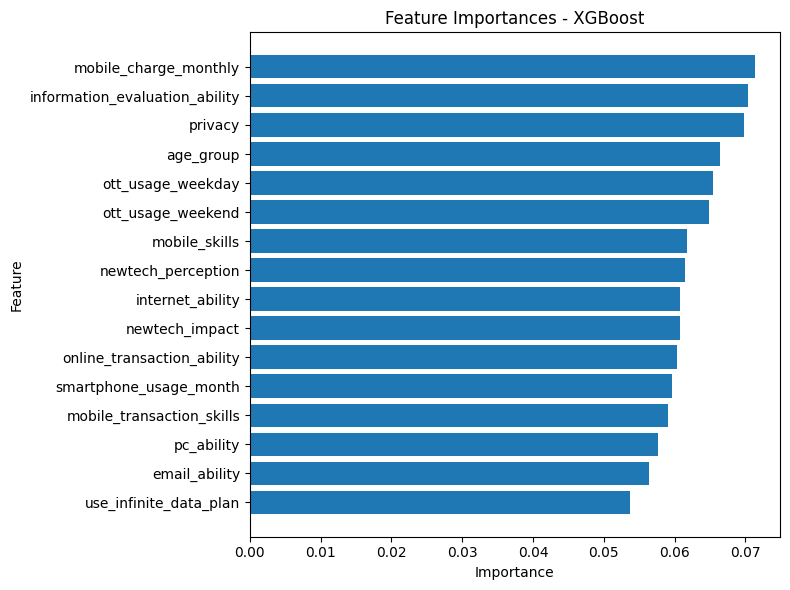

In [42]:
top_n = 20

plot_df = feature_importance_df.head(top_n).sort_values('importance')

plt.figure(figsize=(8, 6))

plt.barh(
    plot_df['feature'],
    plot_df['importance']
)

plt.title(f'Feature Importances - XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

## Feature Importance 해석 (XGBoost)

XGBoost 모델의 Feature Importance를 분석한 결과, 여러 변수들이 비교적 고르게 이탈 예측에 기여하고 있는 것으로 나타났다.
특정 한두 개 변수에 의존하기보다는 **여러 요인이 함께 작용하여 이탈 가능성을 설명하는 구조**로 해석할 수 있다.

가장 중요한 변수는 **`mobile_charge_monthly` (월 통신비)**로 나타났다.
이는 이용자가 지불하는 월 요금 수준이 OTT 서비스 이탈 여부와 밀접하게 관련되어 있음을 시사한다. 일반적으로 월 통신비가 높거나 요금 부담이 큰 사용자일수록 OTT 구독 비용에 민감하게 반응할 가능성이 있으며, 이로 인해 서비스 이용을 중단할 가능성이 존재할 수 있다.

두 번째로 중요한 변수는 **`information_evaluation_ability` (정보 평가 능력)**이며, 이어서 **`privacy` (개인정보 인식)** 변수도 높은 중요도를 보였다. 이는 사용자의 **디지털 리터러시(digital literacy)**와 관련된 요인들이 서비스 이용 지속 여부에 영향을 줄 수 있음을 의미한다. 정보 평가 능력이 높거나 개인정보 보호에 민감한 사용자일수록 플랫폼 선택이나 서비스 변경을 더 적극적으로 고려할 가능성이 있다.

또한 **`age_group` (연령대)** 역시 중요한 변수로 나타났다. 이는 연령에 따라 OTT 서비스 이용 패턴이나 기술 수용도가 다르기 때문으로 해석할 수 있다. 일반적으로 연령대에 따라 콘텐츠 소비 방식, 플랫폼 선호도, 디지털 환경에 대한 익숙함 등이 달라질 수 있으며, 이러한 차이가 이탈 행동에 영향을 줄 수 있다.

OTT 이용 패턴과 직접적으로 관련된 변수인 **`ott_usage_weekday`**와 **`ott_usage_weekend`** 역시 상위 중요 변수로 나타났다. 이는 실제 콘텐츠 이용 빈도와 사용 습관이 이탈 여부와 관련이 있음을 의미한다. OTT 사용 빈도가 낮은 이용자는 서비스에 대한 의존도가 낮아 이탈 가능성이 높을 수 있으며, 반대로 사용 빈도가 높은 이용자는 서비스 유지 가능성이 더 높을 수 있다.

그 외에도 **`mobile_skills`**, **`internet_ability`**, **`online_transaction_ability`**, **`mobile_transaction_skills`**, **`pc_ability`**, **`email_ability`** 등 다양한 **디지털 활용 능력 관련 변수**들이 중요 변수로 나타났다. 이는 단순한 이용량 변수뿐 아니라 **사용자의 디지털 기술 활용 수준과 기술에 대한 인식**이 OTT 서비스 유지 여부에 영향을 줄 수 있음을 시사한다.

또한 **`newtech_perception`**과 **`newtech_impact`**와 같은 변수들은 사용자가 새로운 기술을 어떻게 인식하고 받아들이는지에 대한 태도를 나타내는데, 이러한 요인 역시 플랫폼 이용 지속 여부에 일정한 영향을 줄 수 있는 것으로 보인다.

마지막으로 **`smartphone_usage_month` (월 스마트폰 사용량)**과 **`use_infinite_data_plan` (무제한 데이터 요금제 사용 여부)** 역시 일정 수준의 중요도를 보였다. 이는 모바일 데이터 사용 환경이나 스마트폰 이용 습관 역시 OTT 서비스 사용 패턴과 연관될 수 있음을 보여준다.

종합하면, 이번 모델에서는 **요금 관련 요인, OTT 이용 패턴, 연령대, 그리고 디지털 역량 및 기술 인식**이 복합적으로 작용하여 OTT 서비스 이탈을 설명하고 있는 것으로 해석할 수 있다.
특히 디지털 활용 능력과 관련된 변수들이 다수 포함된 점은, 단순한 콘텐츠 소비 패턴뿐 아니라 **사용자의 기술 환경과 디지털 역량이 OTT 서비스 유지 여부에 중요한 역할을 할 가능성**을 시사한다.